Turbines found: ['fixed', 'floating']


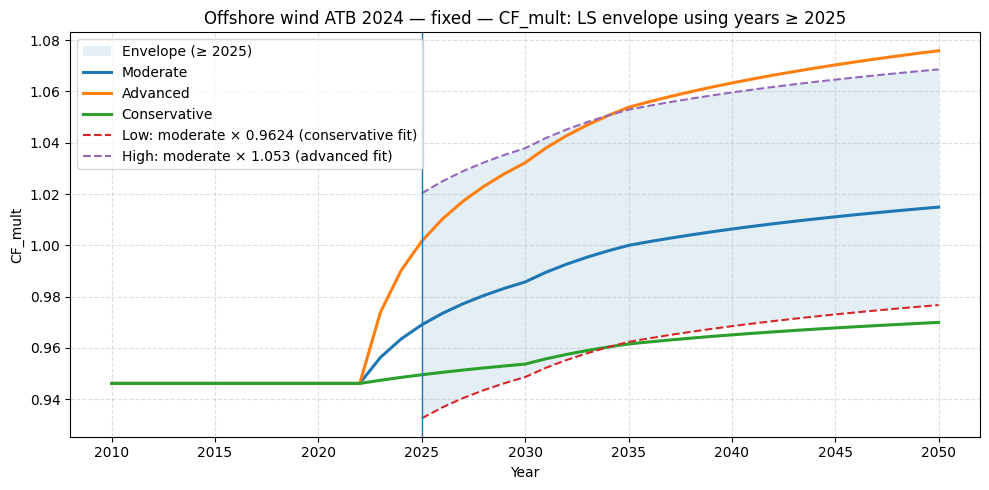

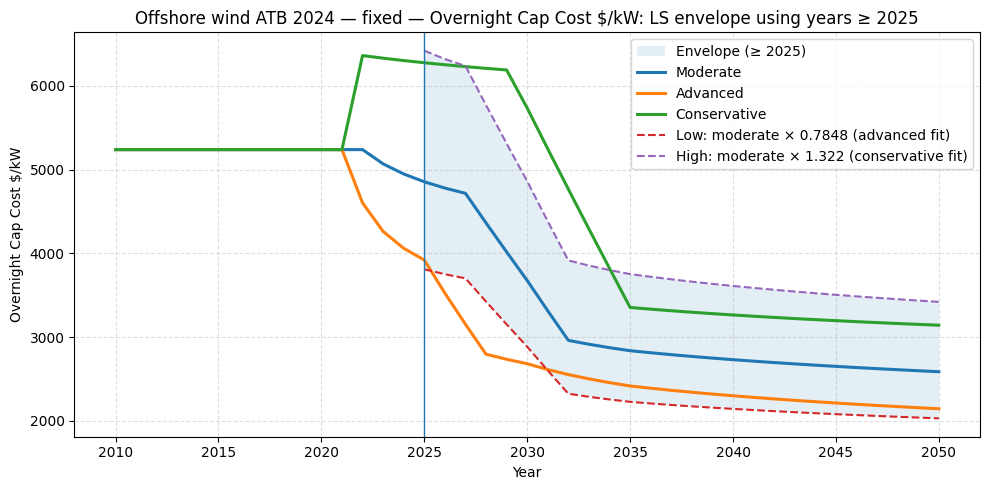

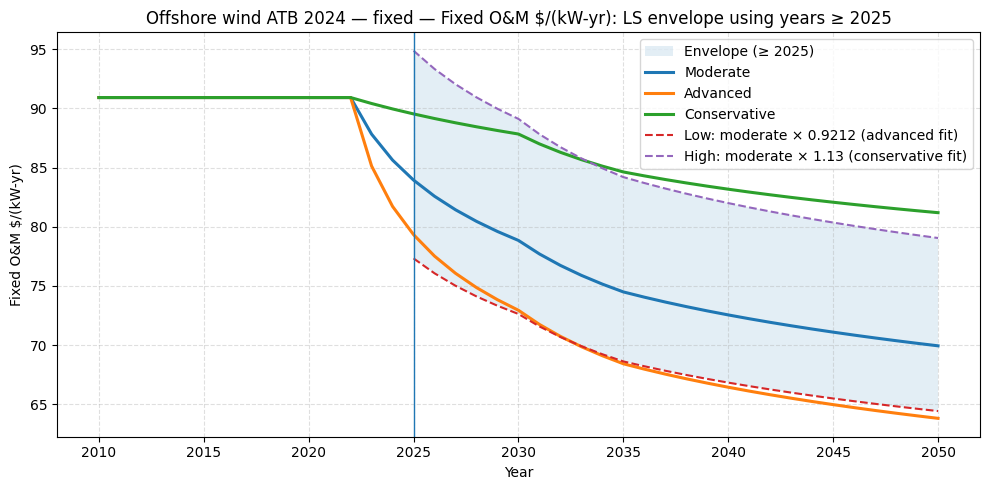

/tmp/ipython-input-3988908319.py:100: RuntimeWarning: All-NaN axis encountered
  low_mult = float(np.nanmin([mA, mC]))
/tmp/ipython-input-3988908319.py:101: RuntimeWarning: All-NaN axis encountered
  high_mult = float(np.nanmax([mA, mC]))


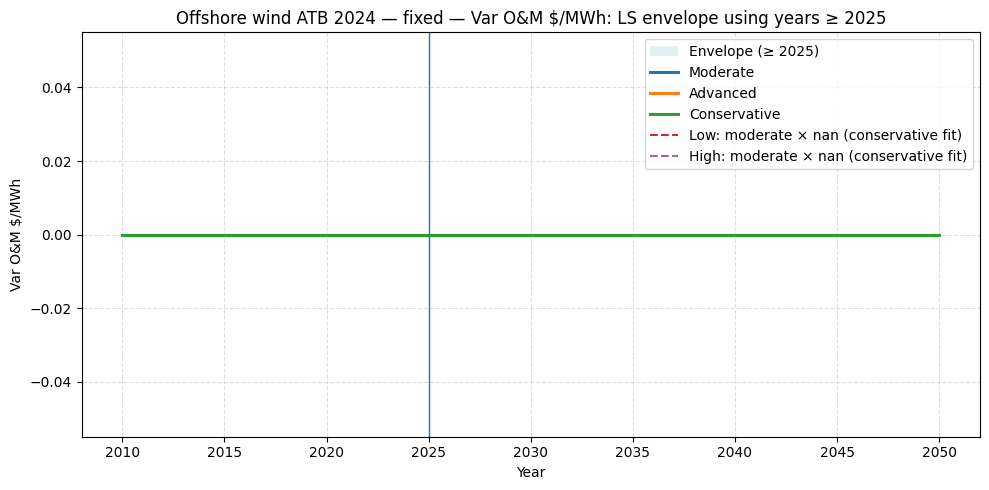

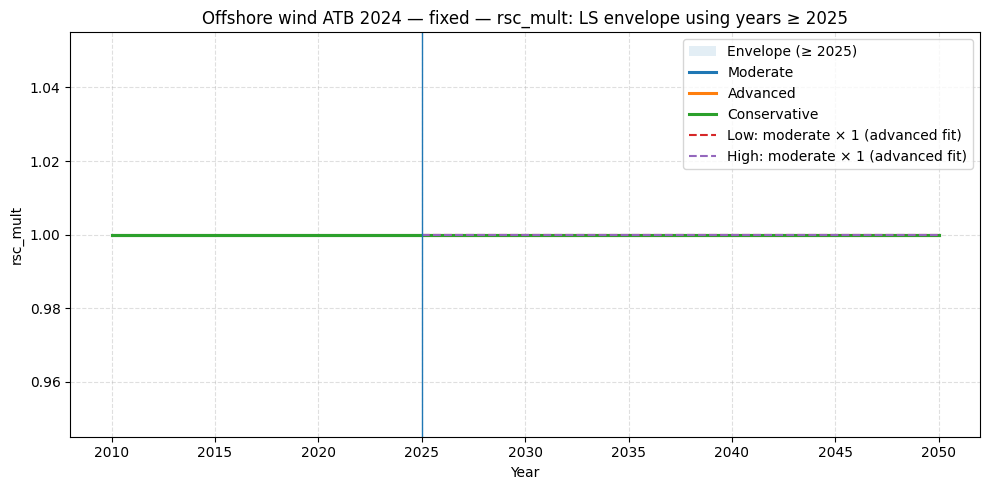

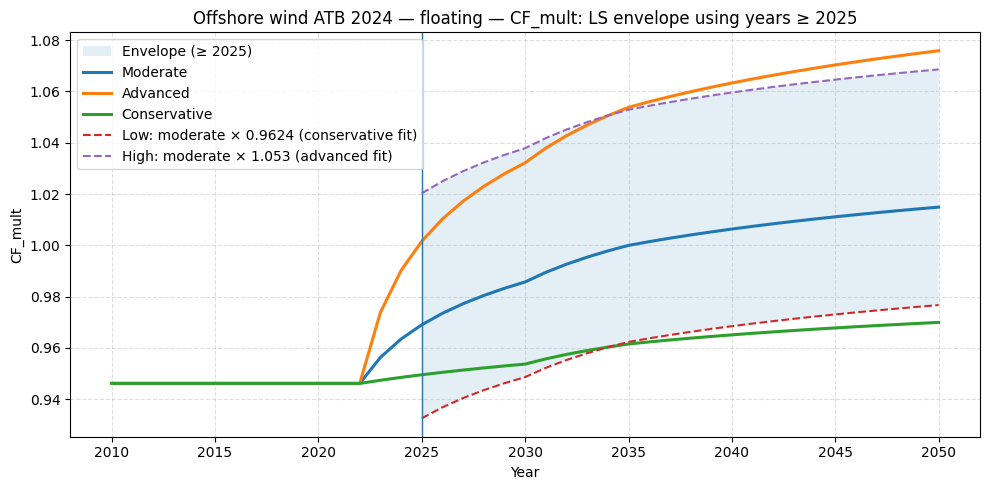

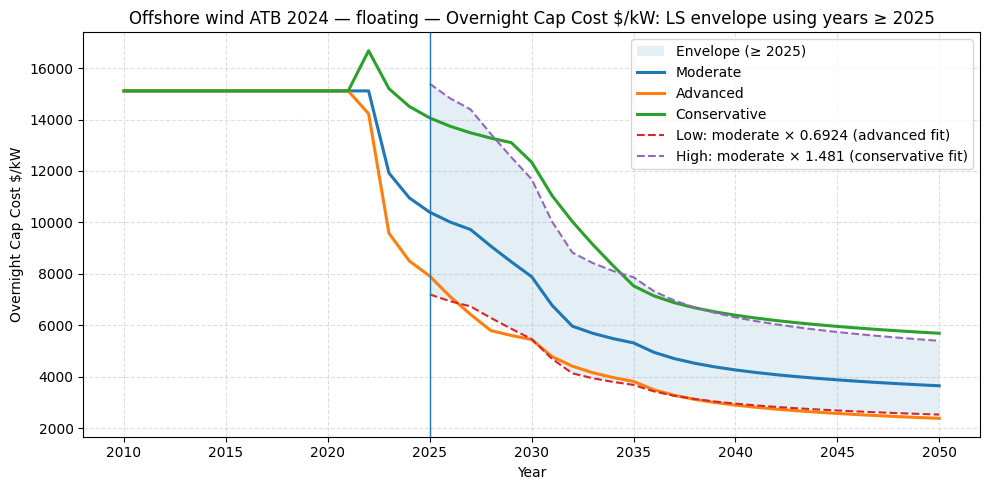

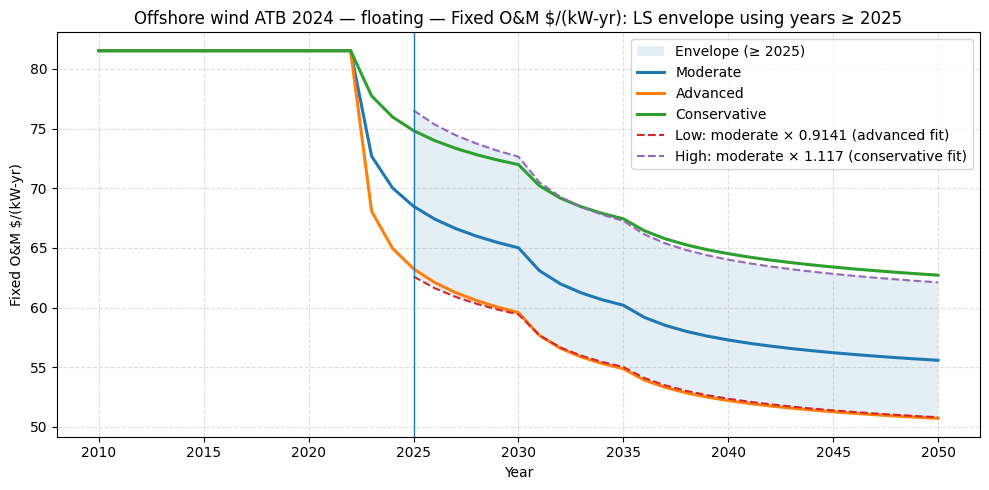

/tmp/ipython-input-3988908319.py:100: RuntimeWarning: All-NaN axis encountered
  low_mult = float(np.nanmin([mA, mC]))
/tmp/ipython-input-3988908319.py:101: RuntimeWarning: All-NaN axis encountered
  high_mult = float(np.nanmax([mA, mC]))


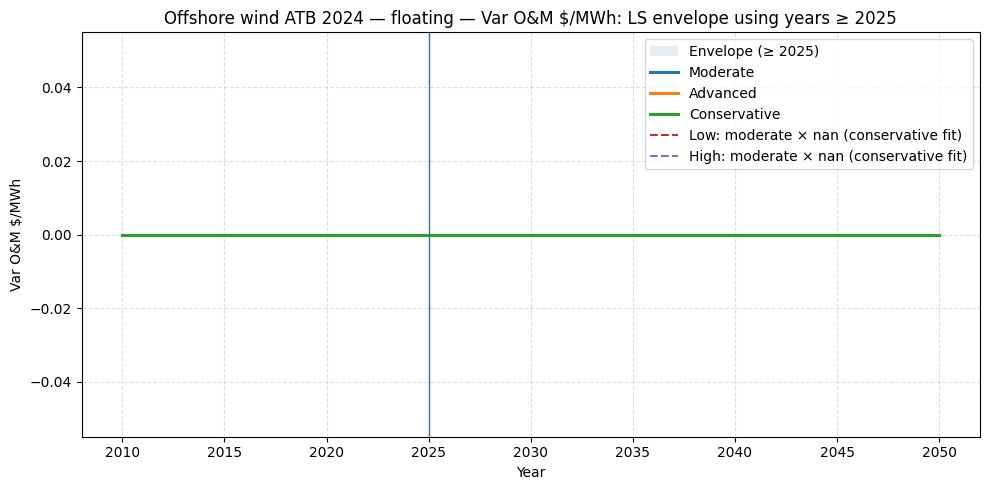

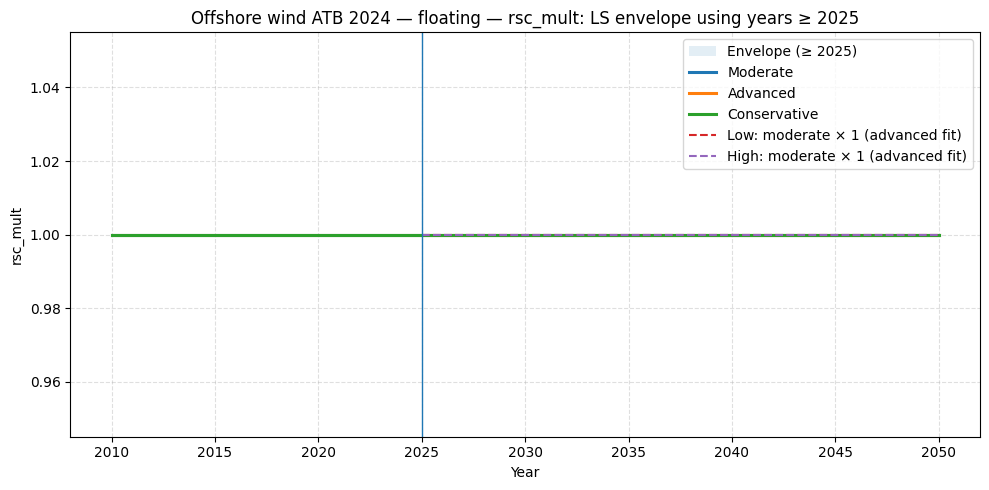

,Turbine,metric,mA,mC,low_mult,high_mult,low_ref,high_ref,n_years_fit,fit_year_min,fit_year_max
0,fixed,CF_mult,1.052892,0.962373,0.962373,1.052892,conservative,advanced,26,2025,2050
1,fixed,Overnight Cap Cost $/kW,0.784806,1.322324,0.784806,1.322324,advanced,conservative,26,2025,2050
2,fixed,Fixed O&M $/(kW-yr),0.921210,1.130169,0.921210,1.130169,advanced,conservative,26,2025,2050
3,fixed,Var O&M $/MWh,NaN,NaN,NaN,NaN,conservative,conservative,26,2025,2050
4,fixed,rsc_mult,1.000000,1.000000,1.000000,1.000000,advanced,advanced,26,2025,2050
5,floating,CF_mult,1.052892,0.962373,0.962373,1.052892,conservative,advanced,26,2025,2050
6,floating,Overnight Cap Cost $/kW,0.692354,1.480643,0.692354,1.480643,advanced,conservative,26,2025,2050
7,floating,Fixed O&M $/(kW-yr),0.914069,1.117492,0.914069,1.117492,advanced,conservative,26,2025,2050
8,floating,Var O&M $/MWh,NaN,NaN,NaN,NaN,conservative,conservative,26,2025,2050
9,floating,rsc_mult,1.000000,1.000000,1.000000,1.000000,advanced,advanced,26,2025,2050


Saved: ofs_wind_envelope_multipliers.csv


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------
# CONFIG (OFFSHORE WIND ATB 2024)
# ---------------------------
FILE_URLS = {
    "advanced": "https://raw.githubusercontent.com/NREL/ReEDS-2.0/refs/heads/main/inputs/plant_characteristics/ofs-wind_ATB_2024_advanced.csv#/",
    "moderate": "https://raw.githubusercontent.com/NREL/ReEDS-2.0/refs/heads/main/inputs/plant_characteristics/ofs-wind_ATB_2024_moderate.csv#/",
    "conservative": "https://raw.githubusercontent.com/NREL/ReEDS-2.0/refs/heads/main/inputs/plant_characteristics/ofs-wind_ATB_2024_conservative.csv#/",
}

# Your file has two turbines: fixed, floating.
# Set to None to run both; or set to "fixed" or "floating" to run one.
TURBINE_FILTER = None  # "fixed" | "floating" | None

# Column names in this offshore wind file
COL_TURBINE = "Turbine"
COL_YEAR = "Year"

# Metrics to envelope (must be numeric)
METRICS = [
    "CF_mult",
    "Overnight Cap Cost $/kW",
    "Fixed O&M $/(kW-yr)",
    "Var O&M $/MWh",
    "rsc_mult",
]

# Fit multipliers using years >= START_YEAR, then show envelope from START_YEAR onward
START_YEAR = 2025

SAVE_CSV = True
OUT_CSV = "ofs_wind_envelope_multipliers.csv"


# ---------------------------
# HELPERS
# ---------------------------
def _clean_url(url: str) -> str:
    """Remove URL fragments like '#/' that can break pd.read_csv over HTTP."""
    return url.split("#", 1)[0]

def load_from_urls(urls: dict) -> pd.DataFrame:
    dfs = []
    for scen, url in urls.items():
        df = pd.read_csv(_clean_url(url))
        df["scenario"] = scen
        dfs.append(df)

    out = pd.concat(dfs, ignore_index=True)

    # Standardize year
    out[COL_YEAR] = pd.to_numeric(out[COL_YEAR], errors="coerce")
    out = out.dropna(subset=[COL_YEAR]).copy()
    out[COL_YEAR] = out[COL_YEAR].astype(int)

    # Ensure metrics numeric
    for col in METRICS:
        if col in out.columns:
            out[col] = pd.to_numeric(out[col], errors="coerce")

    # Optional turbine filter
    if TURBINE_FILTER is not None:
        out = out[out[COL_TURBINE] == TURBINE_FILTER].copy()

    return out.sort_values(["scenario", COL_TURBINE, COL_YEAR]).reset_index(drop=True)

def fit_multiplier_ls(moderate: pd.Series, target: pd.Series) -> float:
    """
    Least-squares multiplier m minimizing || m*moderate - target ||^2
    => m = (moderate·target) / (moderate·moderate)
    """
    m = moderate.values.astype(float)
    y = target.values.astype(float)
    denom = float(np.dot(m, m))
    if denom == 0:
        return np.nan
    return float(np.dot(m, y) / denom)

def envelope_multipliers_for_group(df_g: pd.DataFrame, metric: str, start_year: int = 2025) -> dict:
    piv = (df_g[[COL_YEAR, "scenario", metric]]
           .dropna(subset=[COL_YEAR, metric])
           .pivot(index=COL_YEAR, columns="scenario", values=metric)
           .sort_index())

    for s in ["moderate", "advanced", "conservative"]:
        if s not in piv.columns:
            raise ValueError(f"Missing scenario '{s}' for metric='{metric}'. Found: {list(piv.columns)}")

    window = piv.loc[piv.index >= start_year].dropna(subset=["moderate", "advanced", "conservative"], how="any")
    if len(window) < 2:
        raise ValueError(f"Not enough overlapping years >= {start_year} for metric='{metric}'.")

    M = window["moderate"]
    mA = fit_multiplier_ls(M, window["advanced"])
    mC = fit_multiplier_ls(M, window["conservative"])

    low_mult = float(np.nanmin([mA, mC]))
    high_mult = float(np.nanmax([mA, mC]))
    low_ref = "advanced" if mA <= mC else "conservative"
    high_ref = "advanced" if mA >= mC else "conservative"

    return {
        "metric": metric,
        "mA": mA,
        "mC": mC,
        "low_mult": low_mult,
        "high_mult": high_mult,
        "low_ref": low_ref,
        "high_ref": high_ref,
        "n_years_fit": int(len(window)),
        "fit_year_min": int(window.index.min()),
        "fit_year_max": int(window.index.max()),
    }

def plot_with_envelope_for_group(df_g: pd.DataFrame, turbine: str, metric: str, start_year: int = 2025):
    info = envelope_multipliers_for_group(df_g, metric, start_year=start_year)

    piv = (df_g[[COL_YEAR, "scenario", metric]]
           .dropna(subset=[COL_YEAR, metric])
           .pivot(index=COL_YEAR, columns="scenario", values=metric)
           .sort_index())

    years = piv.index
    M_all = piv["moderate"]
    env_low = M_all * info["low_mult"]
    env_high = M_all * info["high_mult"]

    mask = years >= start_year
    yrs_env = years[mask]

    plt.figure(figsize=(10, 5))
    plt.fill_between(
        yrs_env,
        env_low.loc[yrs_env].values,
        env_high.loc[yrs_env].values,
        alpha=0.12,
        label=f"Envelope (≥ {start_year})"
    )

    plt.plot(years, piv["moderate"].values, linewidth=2.2, label="Moderate")
    plt.plot(years, piv["advanced"].values, linewidth=2.2, label="Advanced")
    plt.plot(years, piv["conservative"].values, linewidth=2.2, label="Conservative")

    plt.plot(yrs_env, env_low.loc[yrs_env].values, "--",
             label=f"Low: moderate × {info['low_mult']:.4g} ({info['low_ref']} fit)")
    plt.plot(yrs_env, env_high.loc[yrs_env].values, "--",
             label=f"High: moderate × {info['high_mult']:.4g} ({info['high_ref']} fit)")

    plt.axvline(start_year, linewidth=1)
    plt.title(f"Offshore wind ATB 2024 — {turbine} — {metric}: LS envelope using years ≥ {start_year}")
    plt.xlabel("Year")
    plt.ylabel(metric)
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.legend()
    plt.tight_layout()
    plt.show()

    return info


# ---------------------------
# RUN
# ---------------------------
df = load_from_urls(FILE_URLS)

turbines = sorted(df[COL_TURBINE].dropna().unique().tolist())
print("Turbines found:", turbines)

rows = []
for turb in turbines:
    df_g = df[df[COL_TURBINE] == turb].copy()
    for metric in METRICS:
        info = plot_with_envelope_for_group(df_g, turb, metric, start_year=START_YEAR)
        rows.append({
            "Turbine": turb,
            **info
        })

res = pd.DataFrame(rows)
display(res)

if SAVE_CSV:
    res.to_csv(OUT_CSV, index=False)
    print("Saved:", OUT_CSV)


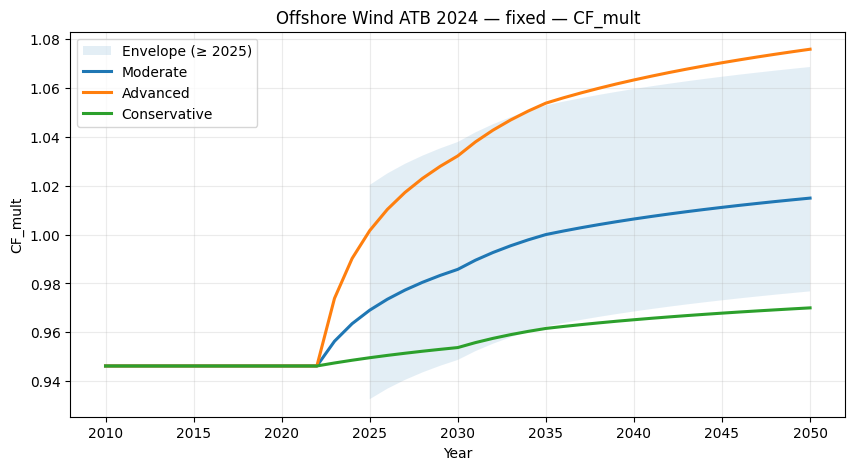

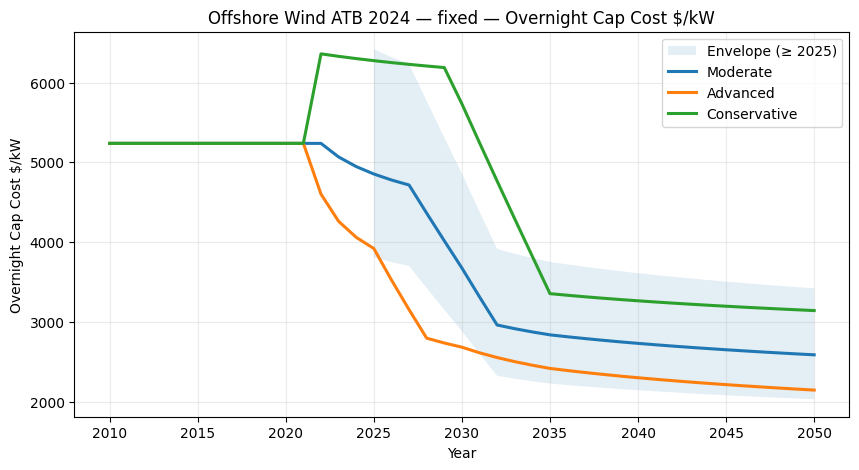

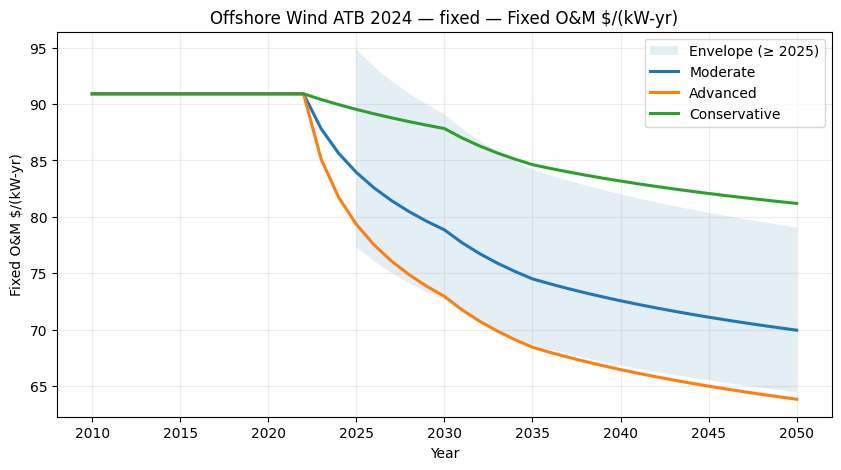

/tmp/ipython-input-2151626025.py:112: RuntimeWarning: All-NaN axis encountered
  low_mult = float(np.nanmin([mA, mC]))
/tmp/ipython-input-2151626025.py:113: RuntimeWarning: All-NaN axis encountered
  high_mult = float(np.nanmax([mA, mC]))


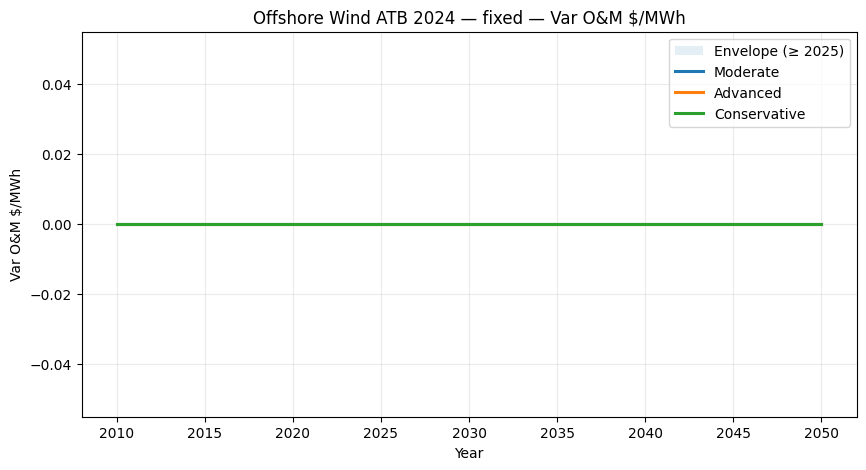

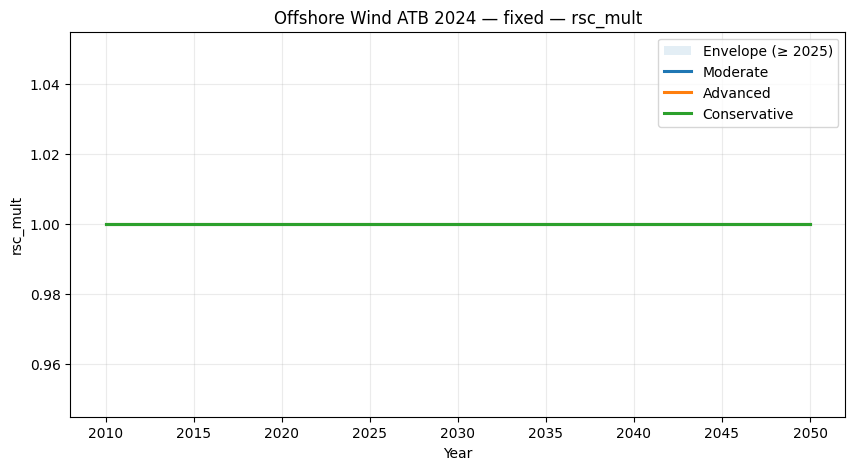

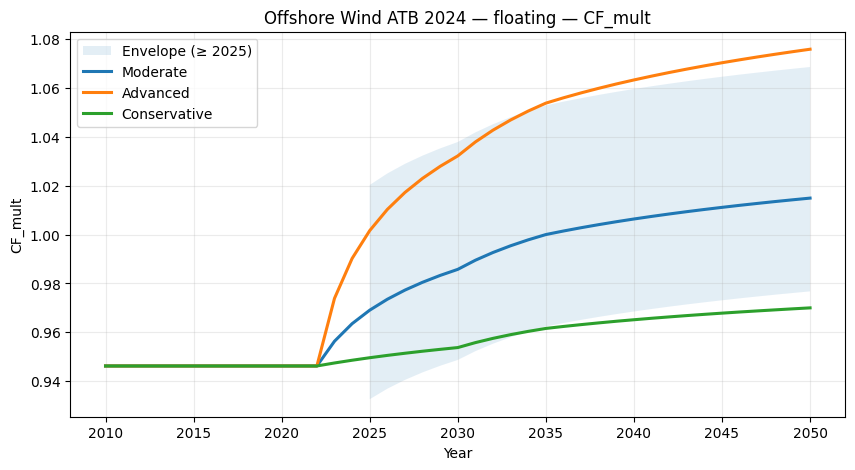

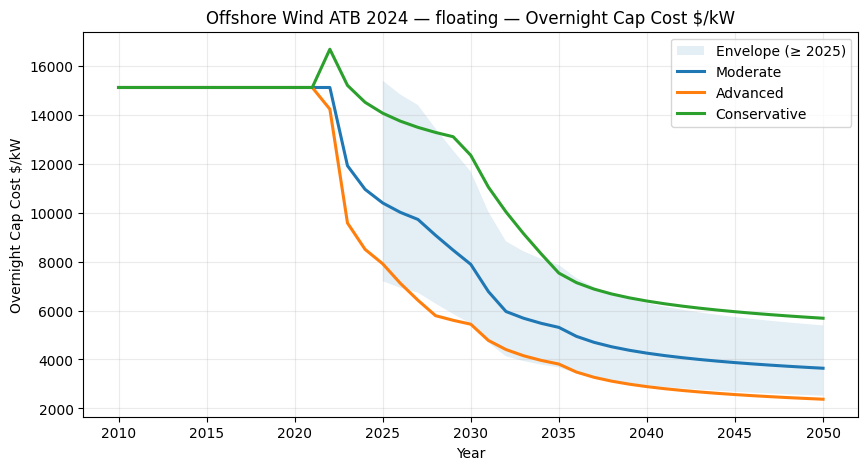

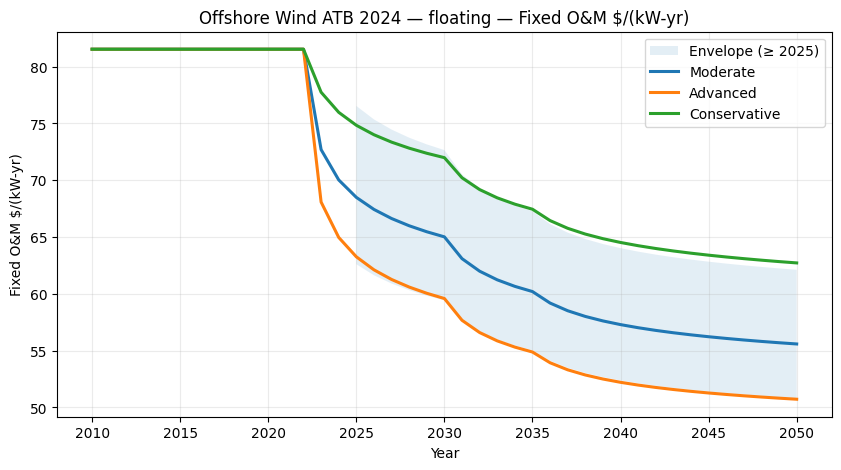

/tmp/ipython-input-2151626025.py:112: RuntimeWarning: All-NaN axis encountered
  low_mult = float(np.nanmin([mA, mC]))
/tmp/ipython-input-2151626025.py:113: RuntimeWarning: All-NaN axis encountered
  high_mult = float(np.nanmax([mA, mC]))


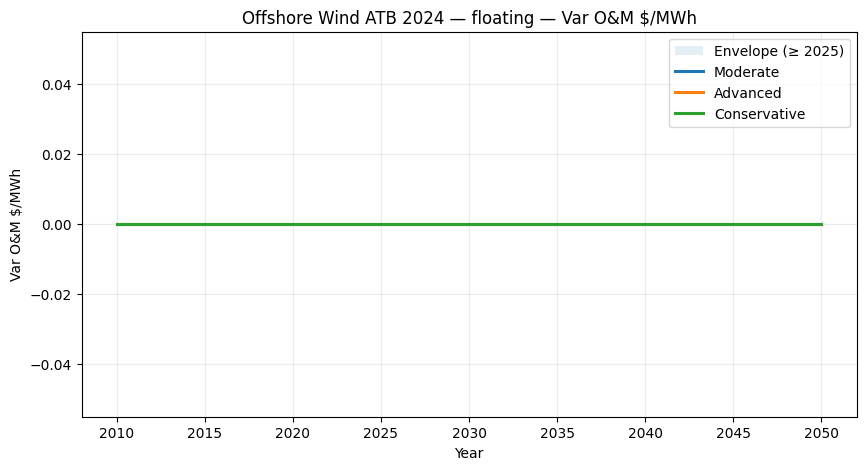

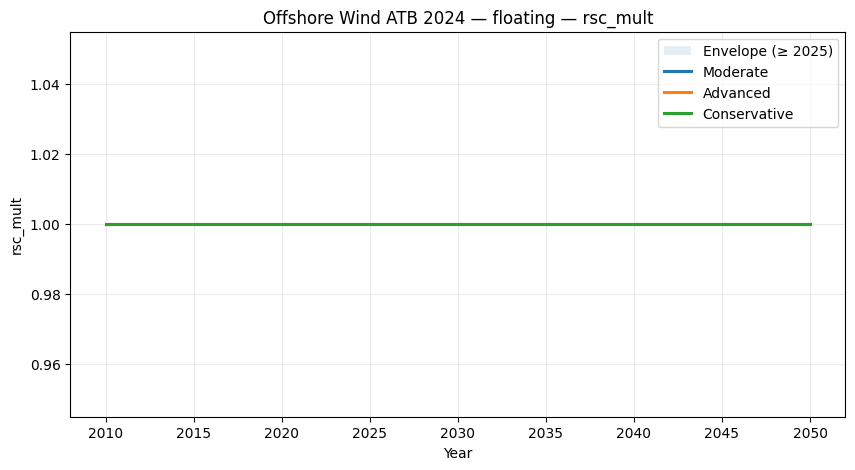

,Turbine,metric,low_mult,high_mult,mA,mC,n_years_fit,fit_year_min,fit_year_max
0,fixed,CF_mult,0.962373,1.052892,1.052892,0.962373,26,2025,2050
1,fixed,Overnight Cap Cost $/kW,0.784806,1.322324,0.784806,1.322324,26,2025,2050
2,fixed,Fixed O&M $/(kW-yr),0.921210,1.130169,0.921210,1.130169,26,2025,2050
3,fixed,Var O&M $/MWh,NaN,NaN,NaN,NaN,26,2025,2050
4,fixed,rsc_mult,1.000000,1.000000,1.000000,1.000000,26,2025,2050
5,floating,CF_mult,0.962373,1.052892,1.052892,0.962373,26,2025,2050
6,floating,Overnight Cap Cost $/kW,0.692354,1.480643,0.692354,1.480643,26,2025,2050
7,floating,Fixed O&M $/(kW-yr),0.914069,1.117492,0.914069,1.117492,26,2025,2050
8,floating,Var O&M $/MWh,NaN,NaN,NaN,NaN,26,2025,2050
9,floating,rsc_mult,1.000000,1.000000,1.000000,1.000000,26,2025,2050


Saved: ofs_wind_envelope_multipliers.csv
First 5 sample multiplier records (list format):
{'sample_id': 0, 'apply_after_year': 2025, 'CF_mult_mult_shared': 1.0324307201242229, 'csv_file': 'ofs_wind_ATB_2024_samples/ofs-wind_ATB_2024_sample_000.csv', 'fixed__capcost_mult': 1.0207110394801413, 'fixed__fom_mult': 1.1006216921677228, 'floating__capcost_mult': 1.2420818898816917, 'floating__fom_mult': 0.9332264290853133}
{'sample_id': 1, 'apply_after_year': 2025, 'CF_mult_mult_shared': 1.0506854546694968, 'csv_file': 'ofs_wind_ATB_2024_samples/ofs-wind_ATB_2024_sample_001.csv', 'fixed__capcost_mult': 1.193931995468342, 'fixed__fom_mult': 1.085465180977588, 'floating__capcost_mult': 0.7933448585969847, 'floating__fom_mult': 1.0056876251727622}
Saved: ofs_wind_ATB_2024_samples/ofs_wind_ATB_2024_sample_multipliers.csv
Saved 2 sampled CSV files to: /content/ofs_wind_ATB_2024_samples


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ===========================
# EXISTING CONFIG (keep names)
# ===========================
FILE_URLS = {
    "advanced": "https://raw.githubusercontent.com/NREL/ReEDS-2.0/refs/heads/main/inputs/plant_characteristics/ofs-wind_ATB_2024_advanced.csv",
    "moderate": "https://raw.githubusercontent.com/NREL/ReEDS-2.0/refs/heads/main/inputs/plant_characteristics/ofs-wind_ATB_2024_moderate.csv",
    "conservative": "https://raw.githubusercontent.com/NREL/ReEDS-2.0/refs/heads/main/inputs/plant_characteristics/ofs-wind_ATB_2024_conservative.csv",
}

TURBINE_FILTER = None  # set to "fixed" or "floating" if you want to run only one
COL_TURBINE = "Turbine"
COL_YEAR = "Year"

METRICS = [
    "CF_mult",
    "Overnight Cap Cost $/kW",
    "Fixed O&M $/(kW-yr)",
    "Var O&M $/MWh",
    "rsc_mult",
]

START_YEAR = 2025
SAVE_CSV = True
OUT_CSV = "ofs_wind_envelope_multipliers.csv"


# ===========================
# NEW CONFIG (sampling rules)
# ===========================
# Apply multipliers ONLY after 2025 => Year > 2025
APPLY_AFTER_YEAR = 2025

# Number of sampled CSVs to create
N_SAMPLES = 2

# Reproducibility
RANDOM_SEED = 42

# Output folder
OUT_DIR = Path("ofs_wind_ATB_2024_samples")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Save multipliers used for each sample (list format as a CSV too)
SAVE_SAMPLES_TABLE = True
SAMPLES_TABLE_CSV = OUT_DIR / "ofs_wind_ATB_2024_sample_multipliers.csv"


# ===========================
# HELPERS (same style as yours)
# ===========================
def _clean_url(url: str) -> str:
    return url.split("#")[0]

def load_from_urls(file_urls: dict) -> pd.DataFrame:
    frames = []
    for scen, url in file_urls.items():
        url = _clean_url(url)
        tmp = pd.read_csv(url)
        tmp["scenario"] = scen
        frames.append(tmp)

    out = pd.concat(frames, ignore_index=True)

    out[COL_YEAR] = pd.to_numeric(out[COL_YEAR], errors="coerce")
    out[COL_TURBINE] = out[COL_TURBINE].astype(str)

    for col in METRICS:
        if col in out.columns:
            out[col] = pd.to_numeric(out[col], errors="coerce")

    return out.sort_values(["scenario", COL_TURBINE, COL_YEAR]).reset_index(drop=True)

def fit_multiplier_ls(moderate: pd.Series, target: pd.Series) -> float:
    m = moderate.values.astype(float)
    y = target.values.astype(float)
    denom = float(np.dot(m, m))
    if denom == 0:
        return np.nan
    return float(np.dot(m, y) / denom)

def envelope_multipliers_for_group(df_g: pd.DataFrame, metric: str, start_year: int = 2025) -> dict:
    piv = (df_g[[COL_YEAR, "scenario", metric]]
           .dropna(subset=[COL_YEAR, metric])
           .pivot_table(index=COL_YEAR, columns="scenario", values=metric, aggfunc="mean")
           .sort_index())

    for s in ["moderate", "advanced", "conservative"]:
        if s not in piv.columns:
            raise ValueError(f"Missing scenario '{s}' for metric='{metric}'. Found: {list(piv.columns)}")

    window = piv.loc[piv.index >= start_year].dropna(subset=["moderate", "advanced", "conservative"])
    if len(window) < 2:
        return {
            "metric": metric,
            "low_mult": np.nan,
            "high_mult": np.nan,
            "mA": np.nan,
            "mC": np.nan,
            "n_years_fit": len(window),
            "fit_year_min": (window.index.min() if len(window) else np.nan),
            "fit_year_max": (window.index.max() if len(window) else np.nan),
        }

    mA = fit_multiplier_ls(window["moderate"], window["advanced"])
    mC = fit_multiplier_ls(window["moderate"], window["conservative"])

    low_mult = float(np.nanmin([mA, mC]))
    high_mult = float(np.nanmax([mA, mC]))

    return {
        "metric": metric,
        "low_mult": low_mult,
        "high_mult": high_mult,
        "mA": mA,
        "mC": mC,
        "n_years_fit": len(window),
        "fit_year_min": int(window.index.min()),
        "fit_year_max": int(window.index.max()),
    }

def plot_with_envelope_for_group(df_g: pd.DataFrame, turb: str, metric: str, start_year: int = 2025) -> dict:
    info = envelope_multipliers_for_group(df_g, metric, start_year=start_year)

    piv = (df_g[[COL_YEAR, "scenario", metric]]
           .dropna(subset=[COL_YEAR, metric])
           .pivot_table(index=COL_YEAR, columns="scenario", values=metric, aggfunc="mean")
           .sort_index())

    years = piv.index
    M_all = piv["moderate"]
    env_low = M_all * info["low_mult"]
    env_high = M_all * info["high_mult"]

    mask = years >= start_year
    yrs_env = years[mask]

    plt.figure(figsize=(10, 5))
    plt.fill_between(
        yrs_env,
        env_low.loc[yrs_env].values,
        env_high.loc[yrs_env].values,
        alpha=0.12,
        label=f"Envelope (≥ {start_year})"
    )
    plt.plot(years, piv["moderate"].values, linewidth=2.2, label="Moderate")
    plt.plot(years, piv["advanced"].values, linewidth=2.2, label="Advanced")
    plt.plot(years, piv["conservative"].values, linewidth=2.2, label="Conservative")
    plt.title(f"Offshore Wind ATB 2024 — {turb} — {metric}")
    plt.xlabel("Year")
    plt.ylabel(metric)
    plt.legend()
    plt.grid(alpha=0.25)
    plt.show()

    return info


# ===========================
# NEW: Sampling + CSV writer
# ===========================
def build_base_moderate(df: pd.DataFrame) -> pd.DataFrame:
    """
    Base = MODERATE case in GitHub format:
    Turbine,Year,CF_mult,Overnight Cap Cost $/kW,Fixed O&M $/(kW-yr),Var O&M $/MWh,rsc_mult
    """
    base = (df[df["scenario"] == "moderate"][[COL_TURBINE, COL_YEAR] + METRICS]
            .dropna(subset=[COL_TURBINE, COL_YEAR])
            .sort_values([COL_TURBINE, COL_YEAR])
            .reset_index(drop=True))
    base = base[[COL_TURBINE, COL_YEAR] + METRICS]
    return base

def sample_uniform(lo: float, hi: float, rng: np.random.Generator) -> float:
    return float(rng.uniform(float(lo), float(hi)))

def apply_rules_after_2025(
    base: pd.DataFrame,
    cf_mult_sample: float,
    capcost_samples_by_turb: dict,
    fom_samples_by_turb: dict,
    apply_after_year: int = 2025,
) -> pd.DataFrame:
    """
    Rules requested:
    - CF_mult: ONE sample value applied to BOTH turbine types for Year > 2025
    - CapCost & Fixed O&M: sample separately per turbine using that turbine's bounds
    - Var O&M and rsc_mult: unchanged (constant)
    """
    out = base.copy()
    mask_year = out[COL_YEAR].astype(int) > int(apply_after_year)

    # CF_mult applies to both fixed/floating
    out.loc[mask_year, "CF_mult"] = out.loc[mask_year, "CF_mult"] * float(cf_mult_sample)

    # CapCost + Fixed O&M apply per turbine type
    for turb in out[COL_TURBINE].unique():
        mask_t = (out[COL_TURBINE] == turb) & mask_year

        if turb in capcost_samples_by_turb:
            out.loc[mask_t, "Overnight Cap Cost $/kW"] = (
                out.loc[mask_t, "Overnight Cap Cost $/kW"] * float(capcost_samples_by_turb[turb])
            )

        if turb in fom_samples_by_turb:
            out.loc[mask_t, "Fixed O&M $/(kW-yr)"] = (
                out.loc[mask_t, "Fixed O&M $/(kW-yr)"] * float(fom_samples_by_turb[turb])
            )

    return out


# ===========================
# RUN: envelope (existing) + sampling (new)
# ===========================
df = load_from_urls(FILE_URLS)

# turbine list
if TURBINE_FILTER is None:
    turbines = sorted(df[COL_TURBINE].dropna().unique().tolist())
else:
    turbines = [str(TURBINE_FILTER)]

# 1) Envelope plots + summary table (same as your workflow)
rows = []
for turb in turbines:
    df_g = df[df[COL_TURBINE] == turb].copy()
    for metric in METRICS:
        info = plot_with_envelope_for_group(df_g, turb, metric, start_year=START_YEAR)
        rows.append({"Turbine": turb, **info})

res = pd.DataFrame(rows)
display(res)

if SAVE_CSV:
    res.to_csv(OUT_CSV, index=False)
    print("Saved:", OUT_CSV)

# 2) Build bounds needed for sampling
#    Var O&M and rsc_mult are constant, so we only need bounds for:
#    - CF_mult (shared across turbines)
#    - CapCost bounds per turbine
#    - Fixed O&M bounds per turbine

# CF_mult bounds: compute per turbine then take intersection-ish by min/max across turbines.
# (Since you noted CF_mult is the same in both classes, these bounds should match anyway.)
cf_bounds_list = []
for turb in turbines:
    df_g = df[df[COL_TURBINE] == turb].copy()
    cf_bounds_list.append(envelope_multipliers_for_group(df_g, "CF_mult", start_year=START_YEAR))

cf_low = float(np.nanmin([d["low_mult"] for d in cf_bounds_list]))
cf_high = float(np.nanmax([d["high_mult"] for d in cf_bounds_list]))

# CapCost & Fixed O&M bounds per turbine
cap_bounds_by_turb = {}
fom_bounds_by_turb = {}
for turb in turbines:
    df_g = df[df[COL_TURBINE] == turb].copy()
    cap_bounds_by_turb[turb] = envelope_multipliers_for_group(df_g, "Overnight Cap Cost $/kW", start_year=START_YEAR)
    fom_bounds_by_turb[turb] = envelope_multipliers_for_group(df_g, "Fixed O&M $/(kW-yr)", start_year=START_YEAR)

# 3) Base moderate in GitHub format
base = build_base_moderate(df)

# 4) Sampling + CSV generation
rng = np.random.default_rng(RANDOM_SEED)
samples_list = []

for k in range(N_SAMPLES):
    # CF_mult: ONE sample shared by both turbines
    if pd.isna(cf_low) or pd.isna(cf_high):
        cf_mult_sample = 1.0
    else:
        cf_mult_sample = sample_uniform(cf_low, cf_high, rng)

    # CapCost & FOM: sample separately per turbine
    cap_samples_by_turb = {}
    fom_samples_by_turb = {}

    for turb in turbines:
        cap_info = cap_bounds_by_turb[turb]
        fom_info = fom_bounds_by_turb[turb]

        # capcost sample
        lo, hi = cap_info["low_mult"], cap_info["high_mult"]
        cap_samples_by_turb[turb] = 1.0 if (pd.isna(lo) or pd.isna(hi)) else sample_uniform(lo, hi, rng)

        # fixed O&M sample
        lo, hi = fom_info["low_mult"], fom_info["high_mult"]
        fom_samples_by_turb[turb] = 1.0 if (pd.isna(lo) or pd.isna(hi)) else sample_uniform(lo, hi, rng)

    # Apply multipliers only after 2025
    sampled_all = apply_rules_after_2025(
        base=base,
        cf_mult_sample=cf_mult_sample,
        capcost_samples_by_turb=cap_samples_by_turb,
        fom_samples_by_turb=fom_samples_by_turb,
        apply_after_year=APPLY_AFTER_YEAR,
    )

    # Enforce exact GitHub column order
    sampled_all = sampled_all[[COL_TURBINE, COL_YEAR] + METRICS]

    out_path = OUT_DIR / f"ofs-wind_ATB_2024_sample_{k:03d}.csv"
    sampled_all.to_csv(out_path, index=False)

    # list-format record: one row per sample, with turbine-specific cap/fom multipliers
    rec = {
        "sample_id": k,
        "apply_after_year": APPLY_AFTER_YEAR,
        "CF_mult_mult_shared": cf_mult_sample,
        "csv_file": str(out_path),
    }
    for turb in turbines:
        rec[f"{turb}__capcost_mult"] = cap_samples_by_turb[turb]
        rec[f"{turb}__fom_mult"] = fom_samples_by_turb[turb]
    samples_list.append(rec)

# Show list-format preview
print("First 5 sample multiplier records (list format):")
for item in samples_list[:5]:
    print(item)

if SAVE_SAMPLES_TABLE:
    samples_table = pd.DataFrame(samples_list)
    samples_table.to_csv(SAMPLES_TABLE_CSV, index=False)
    print("Saved:", SAMPLES_TABLE_CSV)

print(f"Saved {N_SAMPLES} sampled CSV files to: {OUT_DIR.resolve()}")


In [3]:
sample_id_to_plot = 0

sample_record = samples_list[sample_id_to_plot]
sample_csv_path = sample_record['csv_file']

sampled_df = pd.read_csv(sample_csv_path)
display(f"Loaded sample {sample_id_to_plot} from {sample_csv_path}")

'Loaded sample 0 from ofs_wind_ATB_2024_samples/ofs-wind_ATB_2024_sample_000.csv'

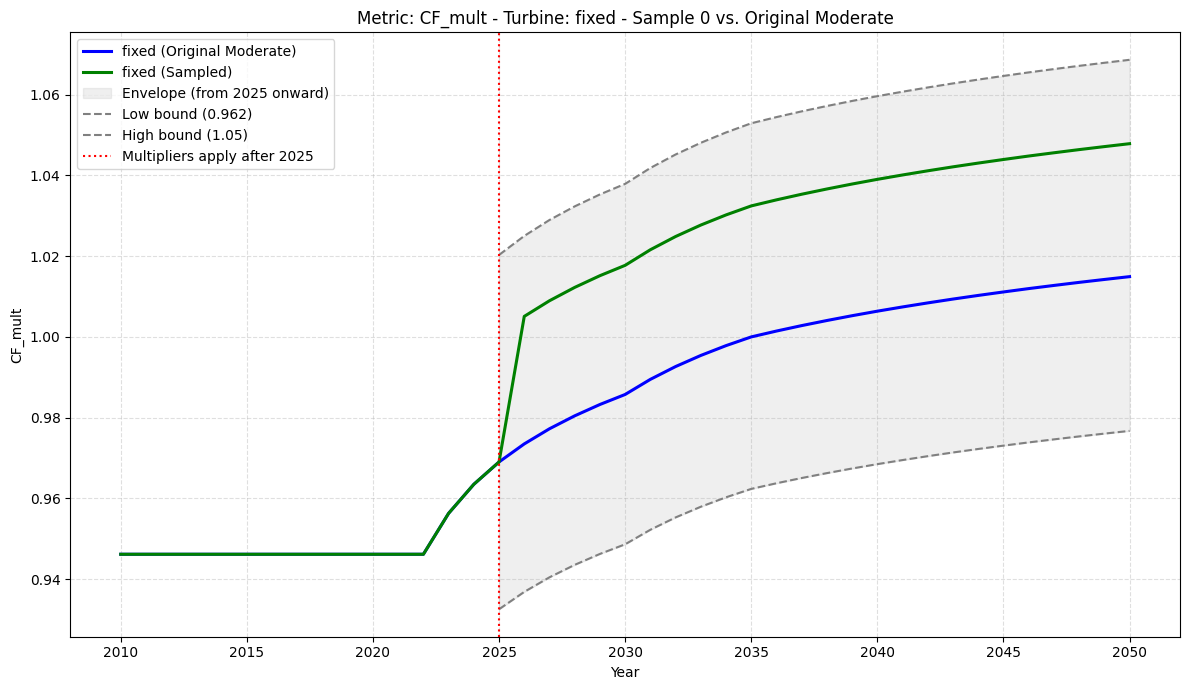

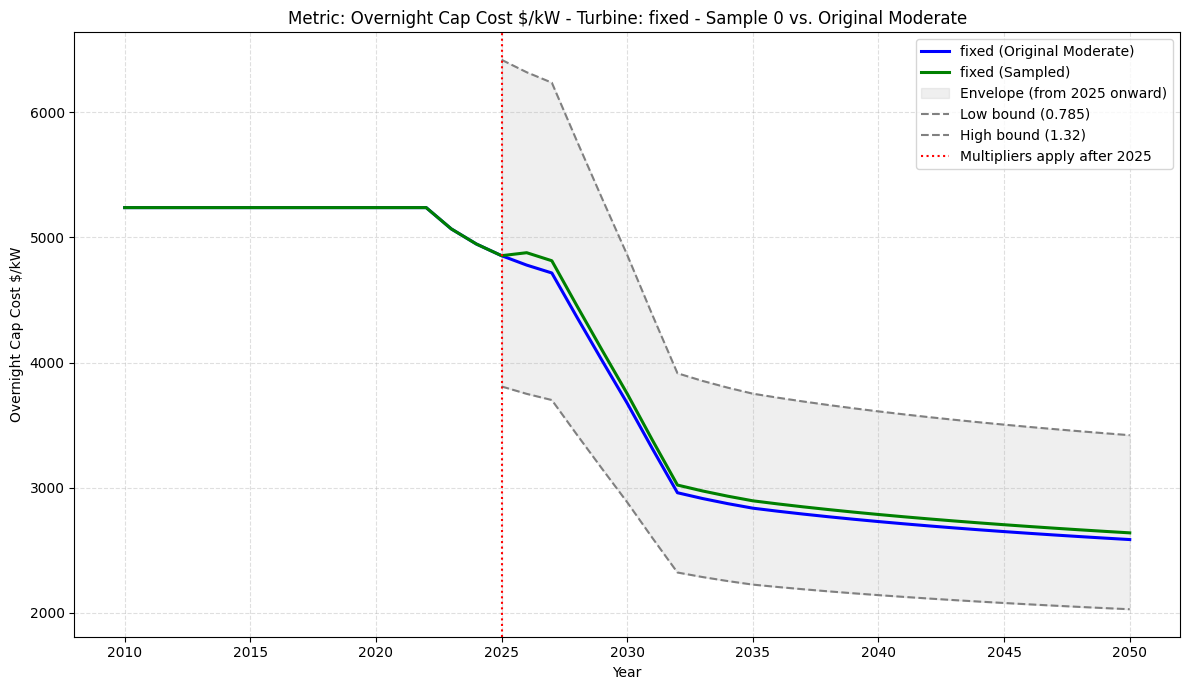

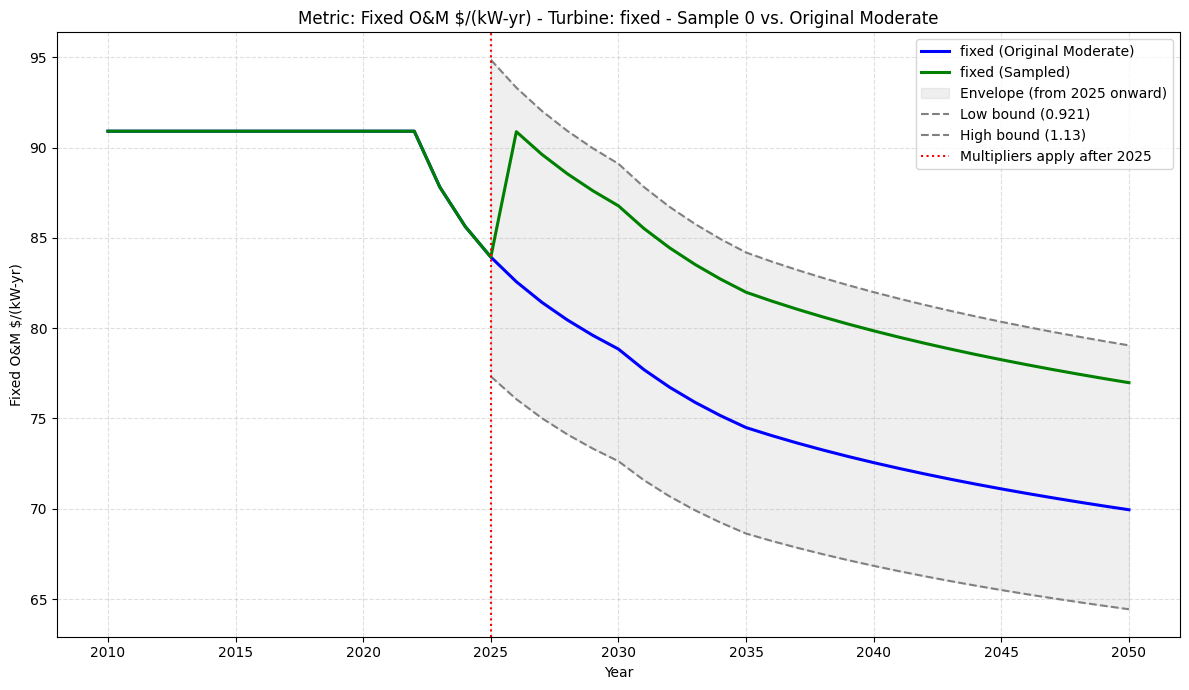

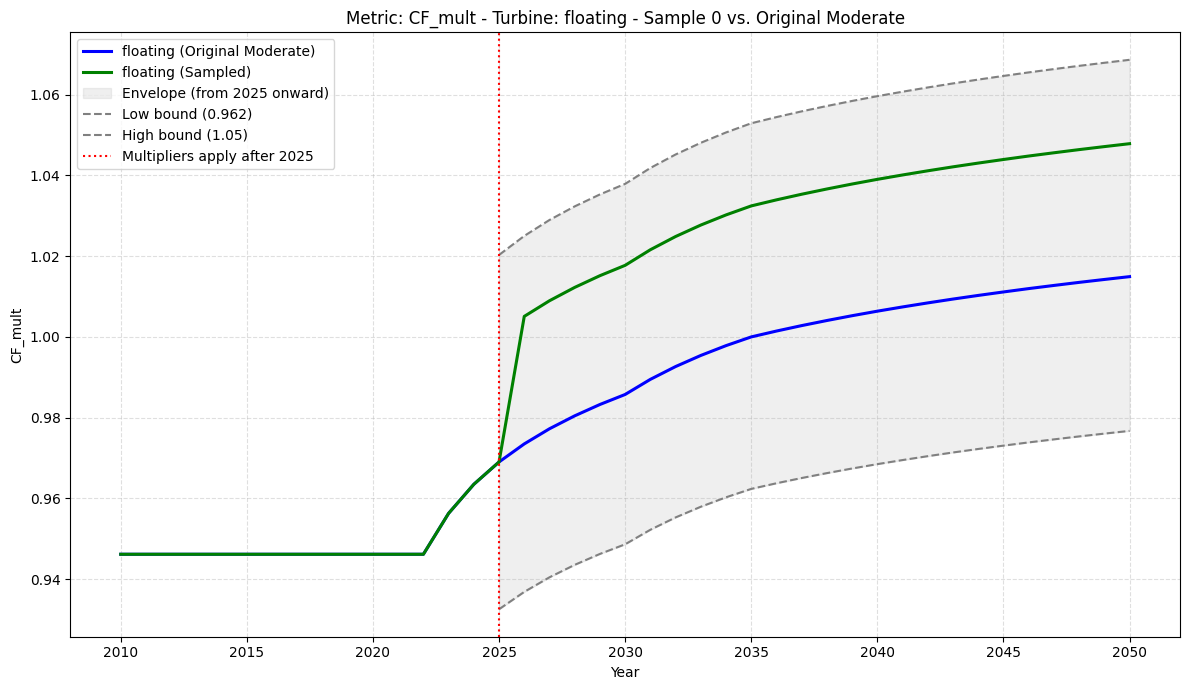

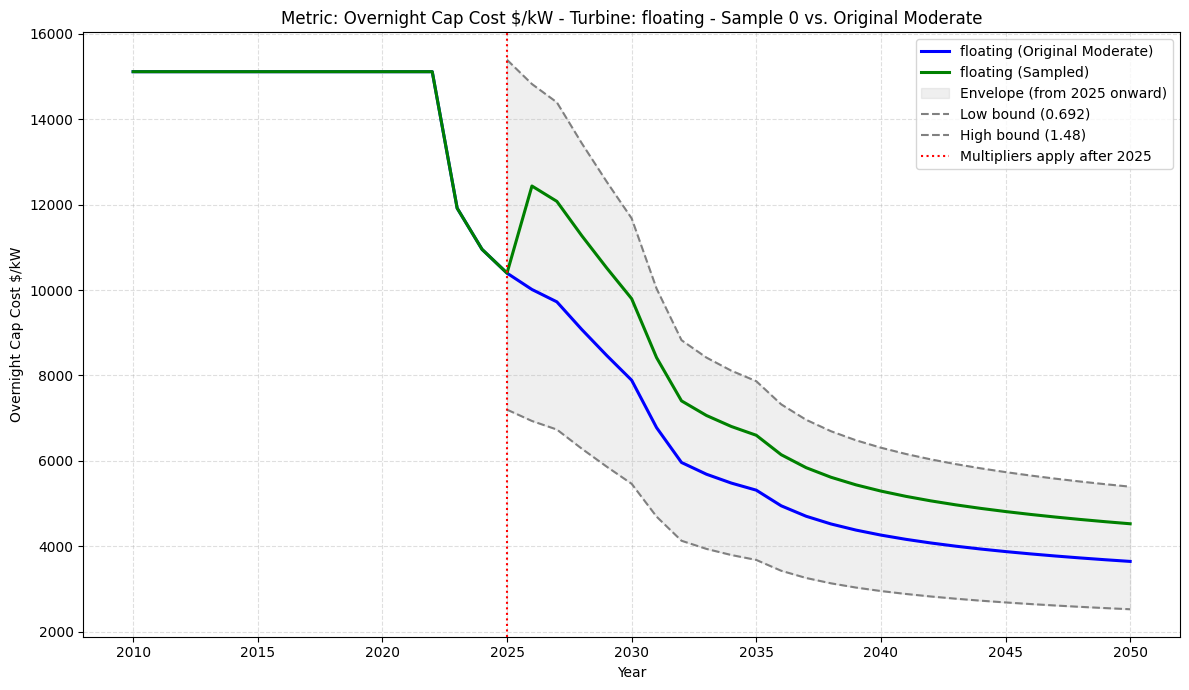

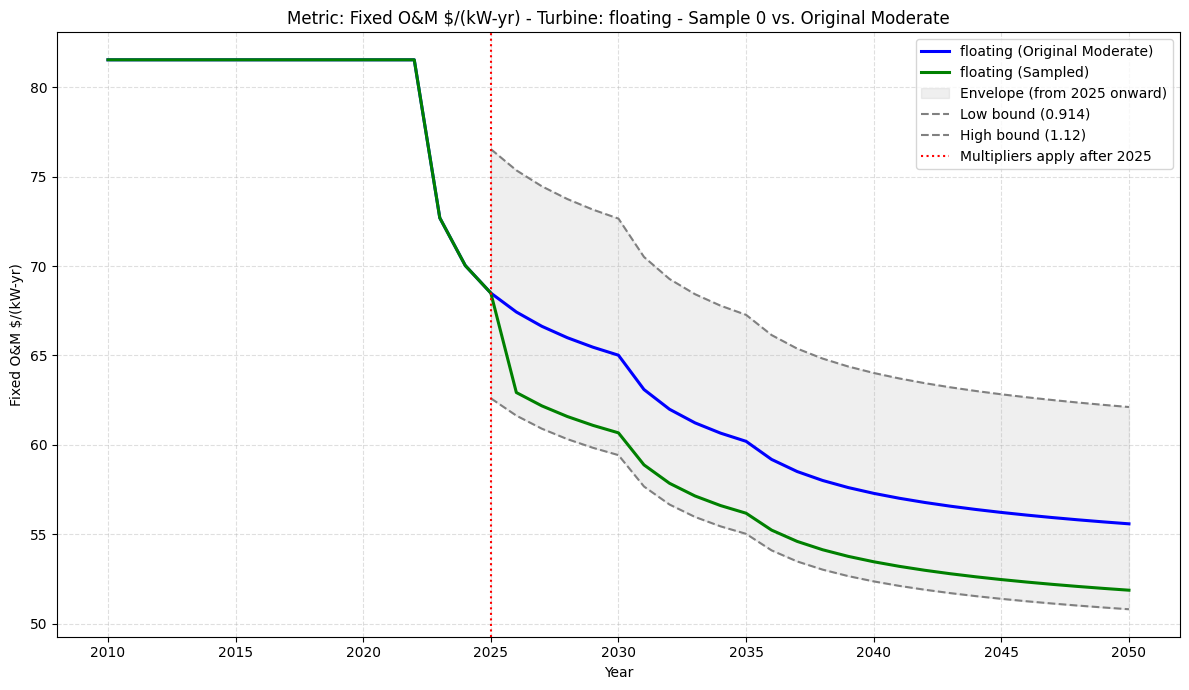

In [4]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

metrics_to_plot = [
    "CF_mult",
    "Overnight Cap Cost $/kW",
    "Fixed O&M $/(kW-yr)",
]

for turb in turbines:
    for metric in metrics_to_plot:
        plt.figure(figsize=(12, 7))

        # Original moderate values for the current turbine and metric
        original_turb_data = base[base[COL_TURBINE] == turb][[COL_YEAR, metric]].copy()
        original_turb_data.set_index(COL_YEAR, inplace=True)
        M_all = original_turb_data[metric]
        years = original_turb_data.index

        # Sampled values for the current turbine and metric
        sampled_turb_data = sampled_df[sampled_df[COL_TURBINE] == turb][[COL_YEAR, metric]].copy()
        sampled_turb_data.set_index(COL_YEAR, inplace=True)

        # Get envelope multipliers for this specific turbine and metric
        info_row = res[(res['Turbine'] == turb) & (res['metric'] == metric)]
        if not info_row.empty:
            low_mult = info_row.iloc[0]['low_mult']
            high_mult = info_row.iloc[0]['high_mult']
        else:
            # Fallback if multipliers are not found (shouldn't happen for these metrics)
            low_mult = 1.0
            high_mult = 1.0

        # Calculate envelope lines
        env_low_series = M_all * low_mult
        env_high_series = M_all * high_mult

        # Mask for years where multipliers are applied (after APPLY_AFTER_YEAR)
        mask_apply_years = years >= APPLY_AFTER_YEAR
        yrs_apply = years[mask_apply_years]

        # Plot original moderate
        plt.plot(years, M_all.values, linewidth=2.2, label=f'{turb} (Original Moderate)', color='blue')

        # Plot sampled data
        plt.plot(years, sampled_turb_data[metric].values, linewidth=2.2, label=f'{turb} (Sampled)', color='green')

        # Plot envelope only if multipliers are meaningful (not NaN and not both 1.0)
        if not (pd.isna(low_mult) or pd.isna(high_mult) or (np.isclose(low_mult, 1.0) and np.isclose(high_mult, 1.0))):
            plt.fill_between(
                yrs_apply,
                env_low_series.loc[yrs_apply].values,
                env_high_series.loc[yrs_apply].values,
                alpha=0.12,
                color='gray',
                label=f"Envelope (from {APPLY_AFTER_YEAR} onward)"
            )
            plt.plot(yrs_apply, env_low_series.loc[yrs_apply].values, "--", color='gray',
                     label=f"Low bound ({low_mult:.3g})")
            plt.plot(yrs_apply, env_high_series.loc[yrs_apply].values, "--", color='gray',
                     label=f"High bound ({high_mult:.3g})")


        plt.axvline(APPLY_AFTER_YEAR, color='red', linestyle=':', label=f'Multipliers apply after {APPLY_AFTER_YEAR}')
        plt.title(f'Metric: {metric} - Turbine: {turb} - Sample {sample_id_to_plot} vs. Original Moderate')
        plt.xlabel('Year')
        plt.ylabel(metric)
        plt.grid(True, linestyle='--', alpha=0.4) # Increased grid visibility
        plt.legend()
        plt.tight_layout()
        plt.show()

In [5]:
from IPython.display import Markdown, display

# Units of the underlying parameters (multipliers themselves are unitless)
metric_units = {
    "CF_mult": r"unitless",                 # CF multiplier is inherently unitless
    "Overnight Cap Cost $/kW": r"\$/kW",
    "Fixed O&M $/(kW-yr)": r"\$/kW-yr",
}

latex_rows = []

# 1) Shared CF_mult bounds row (applies to BOTH fixed/floating)
latex_rows.append(
    rf"CF\_mult (shared: Offshore wind fixed \& floating) & {cf_high:.4f} & {cf_low:.4f} & {metric_units['CF_mult']} (multiplier) \\"
)

# 2) Per-turbine bounds rows for capcost and fixed O&M
for turb in turbines:
    cap_lo = cap_bounds_by_turb[turb]["low_mult"]
    cap_hi = cap_bounds_by_turb[turb]["high_mult"]

    fom_lo = fom_bounds_by_turb[turb]["low_mult"]
    fom_hi = fom_bounds_by_turb[turb]["high_mult"]

    latex_rows.append(
        rf"Offshore wind -- {turb} -- Overnight Cap Cost & {cap_hi:.4f} & {cap_lo:.4f} & {metric_units['Overnight Cap Cost $/kW']} (multiplier) \\"
    )
    latex_rows.append(
        rf"Offshore wind -- {turb} -- Fixed O\&M & {fom_hi:.4f} & {fom_lo:.4f} & {metric_units['Fixed O&M $/(kW-yr)']} (multiplier) \\"
    )

full_latex_table = rf"""
\begin{{table}}[h!]
\centering
\caption{{Sampled Multiplier Bounds and Parameter Units for Offshore Wind ATB 2024}}
\label{{tab:ofs_wind_metric_bounds_units}}
\begin{{tabular}}{{l c c c}}
\toprule
Parameter & Upperbound & Lowerbound & Unit \\
\midrule
{chr(10).join(latex_rows)}
\bottomrule
\end{{tabular}}
\end{{table}}
"""

display(Markdown(f"```latex\n{full_latex_table}\n```"))



```latex

\begin{table}[h!]
\centering
\caption{Sampled Multiplier Bounds and Parameter Units for Offshore Wind ATB 2024}
\label{tab:ofs_wind_metric_bounds_units}
\begin{tabular}{l c c c}
\toprule
Parameter & Upperbound & Lowerbound & Unit \\
\midrule
CF\_mult (shared: Offshore wind fixed \& floating) & 1.0529 & 0.9624 & unitless (multiplier) \\
Offshore wind -- fixed -- Overnight Cap Cost & 1.3223 & 0.7848 & \$/kW (multiplier) \\
Offshore wind -- fixed -- Fixed O\&M & 1.1302 & 0.9212 & \$/kW-yr (multiplier) \\
Offshore wind -- floating -- Overnight Cap Cost & 1.4806 & 0.6924 & \$/kW (multiplier) \\
Offshore wind -- floating -- Fixed O\&M & 1.1175 & 0.9141 & \$/kW-yr (multiplier) \\
\bottomrule
\end{tabular}
\end{table}

```

In [6]:
import numpy as np
import pandas as pd
from pathlib import Path

# -----------------------------
# CONFIG
# -----------------------------
START_YEAR = 2025
APPLY_STRICTLY_AFTER = True   # True => Year > 2025, False => Year >= 2025

OUT_DIR = Path("ofs_wind_ATB_2024_morris")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Your GitHub raw links (Morris)
MORRIS_DESIGN_URL = "https://raw.githubusercontent.com/Raziye-Aghapour/ReEDS_Morris/refs/heads/main/morris_design_r5_p6.csv#/"
FACTOR_MAP_URL    = "https://raw.githubusercontent.com/Raziye-Aghapour/ReEDS_Morris/refs/heads/main/morris_factor_map.csv#/"

# NREL/ReEDS base file (moderate)
OFS_REF_URL = "https://raw.githubusercontent.com/NREL/ReEDS-2.0/refs/heads/main/inputs/plant_characteristics/ofs-wind_ATB_2024_moderate.csv"

# EXACT expected columns in the offshore wind file
REQ_COLS = [
    "Turbine",
    "Year",
    "CF_mult",
    "Overnight Cap Cost $/kW",
    "Fixed O&M $/(kW-yr)",
    "Var O&M $/MWh",
    "rsc_mult",
]

# -----------------------------
# 1) Load Morris inputs
# -----------------------------
design = pd.read_csv(MORRIS_DESIGN_URL.split("#")[0])
factor_map = pd.read_csv(FACTOR_MAP_URL.split("#")[0])

def pick_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None

PARAM_COL  = pick_col(factor_map, ["parameter","Parameter","name","Name","desc","description"])
FACTOR_COL = pick_col(factor_map, ["factor","Factor","id","ID"])
if PARAM_COL is None or FACTOR_COL is None:
    raise ValueError(f"Can't find parameter/factor columns in factor_map. Columns: {list(factor_map.columns)}")

def get_factor_id(param_exact: str) -> str:
    hit = factor_map.loc[factor_map[PARAM_COL].astype(str).str.strip() == param_exact]
    if hit.empty:
        raise ValueError(f"Could not find '{param_exact}' in factor_map[{PARAM_COL}]")
    return str(hit.iloc[0][FACTOR_COL])

# -----------------------------
# 2) Resolve factor IDs (Morris column names)
#    Must match your factor_map "parameter" strings exactly
# -----------------------------
# Shared CF_mult (fixed + floating)
f_cf = get_factor_id("CF_mult (shared: Offshore wind fixed & floating)")

# Turbine-specific capcost & FOM
f_fix_cap = get_factor_id("Offshore wind -- fixed -- Overnight Cap Cost")
f_fix_fom = get_factor_id("Offshore wind -- fixed -- Fixed O&M")

f_flt_cap = get_factor_id("Offshore wind -- floating -- Overnight Cap Cost")
f_flt_fom = get_factor_id("Offshore wind -- floating -- Fixed O&M")

# Ensure these columns exist in design
for f in [f_cf, f_fix_cap, f_fix_fom, f_flt_cap, f_flt_fom]:
    if f not in design.columns:
        raise ValueError(
            f"Design file missing column '{f}'.\n"
            f"Found columns (first 50): {list(design.columns)[:50]}"
        )

# -----------------------------
# 3) Load base NREL moderate file and enforce exact schema
# -----------------------------
base = pd.read_csv(OFS_REF_URL)
missing = [c for c in REQ_COLS if c not in base.columns]
if missing:
    raise ValueError(f"Base file missing columns {missing}. Found: {list(base.columns)}")

base = base[REQ_COLS].copy()
base["Year"] = base["Year"].astype(int)

# Year mask
if APPLY_STRICTLY_AFTER:
    year_mask = base["Year"] > int(START_YEAR)
else:
    year_mask = base["Year"] >= int(START_YEAR)

# Turbine masks (keep turbine names EXACTLY as in the file)
turbines = sorted(base["Turbine"].astype(str).unique().tolist())
if "fixed" not in turbines or "floating" not in turbines:
    print("Warning: turbine names found:", turbines)
mask_fixed = (base["Turbine"].astype(str) == "fixed")
mask_float = (base["Turbine"].astype(str) == "floating")

# -----------------------------
# 4) Generate one CSV per Morris run
# -----------------------------
written = []
for run_idx, row in design.iterrows():
    df_out = base.copy()

    # Extract multipliers from Morris design
    m_cf       = float(row[f_cf])
    m_fix_cap  = float(row[f_fix_cap])
    m_fix_fom  = float(row[f_fix_fom])
    m_flt_cap  = float(row[f_flt_cap])
    m_flt_fom  = float(row[f_flt_fom])

    # Apply CF_mult to BOTH turbines for selected years
    m_apply_all = year_mask
    df_out.loc[m_apply_all, "CF_mult"] = df_out.loc[m_apply_all, "CF_mult"].astype(float) * m_cf

    # Apply fixed turbine multipliers
    m_apply_fixed = year_mask & mask_fixed
    df_out.loc[m_apply_fixed, "Overnight Cap Cost $/kW"] = (
        df_out.loc[m_apply_fixed, "Overnight Cap Cost $/kW"].astype(float) * m_fix_cap
    )
    df_out.loc[m_apply_fixed, "Fixed O&M $/(kW-yr)"] = (
        df_out.loc[m_apply_fixed, "Fixed O&M $/(kW-yr)"].astype(float) * m_fix_fom
    )

    # Apply floating turbine multipliers
    m_apply_float = year_mask & mask_float
    df_out.loc[m_apply_float, "Overnight Cap Cost $/kW"] = (
        df_out.loc[m_apply_float, "Overnight Cap Cost $/kW"].astype(float) * m_flt_cap
    )
    df_out.loc[m_apply_float, "Fixed O&M $/(kW-yr)"] = (
        df_out.loc[m_apply_float, "Fixed O&M $/(kW-yr)"].astype(float) * m_flt_fom
    )

    # Keep exact column order
    df_out = df_out[REQ_COLS]

    fp = OUT_DIR / f"ofs-wind_ATB_2024_morris_{run_idx:03d}.csv"
    df_out.to_csv(fp, index=False)

    written.append({
        "run_id": run_idx,
        "file": fp.name,
        "CF_mult_shared": m_cf,
        "fixed_cap_mult": m_fix_cap,
        "fixed_fom_mult": m_fix_fom,
        "floating_cap_mult": m_flt_cap,
        "floating_fom_mult": m_flt_fom,
        "year_rule": ("> 2025" if APPLY_STRICTLY_AFTER else ">= 2025"),
    })

# Manifest for traceability/debugging
manifest = pd.DataFrame(written)
manifest.to_csv(OUT_DIR / "manifest.csv", index=False)

print(f"Done. Wrote {len(written)} CSVs to: {OUT_DIR.resolve()}")
print("Manifest:", (OUT_DIR / "manifest.csv").resolve())
print("\nPreview first output:")
print(pd.read_csv(OUT_DIR / "ofs-wind_ATB_2024_morris_000.csv").head(10).to_string(index=False))


Done. Wrote 200 CSVs to: /content/ofs_wind_ATB_2024_morris
Manifest: /content/ofs_wind_ATB_2024_morris/manifest.csv

Preview first output:
Turbine  Year  CF_mult  Overnight Cap Cost $/kW  Fixed O&M $/(kW-yr)  Var O&M $/MWh  rsc_mult
  fixed  2010  0.94619                5237.4605              90.9107            0.0       1.0
  fixed  2011  0.94619                5237.4605              90.9107            0.0       1.0
  fixed  2012  0.94619                5237.4605              90.9107            0.0       1.0
  fixed  2013  0.94619                5237.4605              90.9107            0.0       1.0
  fixed  2014  0.94619                5237.4605              90.9107            0.0       1.0
  fixed  2015  0.94619                5237.4605              90.9107            0.0       1.0
  fixed  2016  0.94619                5237.4605              90.9107            0.0       1.0
  fixed  2017  0.94619                5237.4605              90.9107            0.0       1.0
  fixed  2018  

In [7]:
from pathlib import Path
import shutil

OUT_DIR = Path("ofs_wind_ATB_2024_morris")  # <- must match your script
zip_name = "ofs_wind_ATB_2024_morris"

# create gas_ccs_ATB_2024_morris_outputs.zip
shutil.make_archive(zip_name, "zip", OUT_DIR)

print("Created:", f"{zip_name}.zip")

Created: ofs_wind_ATB_2024_morris.zip
